# Stored restriction maps visualisations

## 1. Imports

In [ ]:
import torch

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import networkx as nx

#Cornell
maps = torch.load("/Users/luigifracassetti/projects/neural-sheaf-diffusion/results/maps/DiagSheaf_cornell_fold0_seed43_20260317_111032.pt")

print(type(maps))

<class 'torch.Tensor'>


## 2. Inspection

In [238]:
print(type(maps))
print(len(maps) if hasattr(maps, '__len__') else "Not iterable")

# If it's a tensor
if isinstance(maps, torch.Tensor):
    print(maps.shape)

# If it's a list or dict
if isinstance(maps, (list, tuple)):
    print(type(maps[0]), maps[0].shape)

if isinstance(maps, dict):
    print(maps.keys())

print(maps[:10])

<class 'torch.Tensor'>
554
torch.Size([554, 3])
tensor([[ 0.0000e+00,  4.2000e+01, -7.4906e-01],
        [ 1.0000e+00,  8.2000e+01, -7.0789e-01],
        [ 1.0000e+00,  9.0000e+01, -5.6676e-01],
        [ 1.0000e+00,  9.9000e+01, -6.7800e-01],
        [ 1.0000e+00,  1.4800e+02, -3.5002e-01],
        [ 2.0000e+00,  4.2000e+01, -6.1222e-01],
        [ 3.0000e+00,  4.2000e+01, -6.9459e-01],
        [ 3.0000e+00,  1.6300e+02, -1.2523e-01],
        [ 4.0000e+00,  8.0000e+00, -2.6202e-01],
        [ 4.0000e+00,  2.5000e+01,  5.0195e-01]])


## 3. Boundary Map

In [239]:
print(maps)

tensor([[ 0.0000e+00,  4.2000e+01, -7.4906e-01],
        [ 1.0000e+00,  8.2000e+01, -7.0789e-01],
        [ 1.0000e+00,  9.0000e+01, -5.6676e-01],
        ...,
        [ 1.7800e+02,  1.4800e+02, -1.8721e-01],
        [ 1.6700e+02,  1.4900e+02, -6.7951e-01],
        [ 1.6000e+02,  1.5700e+02, -3.4002e-02]])


In [240]:
df = pd.DataFrame(maps.cpu().tolist(),columns=["source", "target", "map_value"])

df[["source", "target"]] = df[["source", "target"]].astype(int)
df.sort_values(by=["source", "target"], ascending=[True, True], inplace=True)
df

,source,target,map_value
0,0,42,-0.749060
1,1,82,-0.707890
2,1,90,-0.566755
3,1,99,-0.677995
4,1,148,-0.350023
...,...,...,...
486,180,71,-0.812136
534,180,124,-0.694131
545,180,142,-0.319210
452,181,42,-0.206648


In [241]:
display(df[(df["source"] == 42) & (df["target"] == 0)])
display(df[(df["source"] == 0) & (df["target"] == 42)])

,source,target,map_value
277,42,0,-0.037439


,source,target,map_value
0,0,42,-0.74906


In [242]:
df_low = df[df["source"] <= df["target"]]
display(df_low)

df_high = df[df["source"] >= df["target"]]
display(df_high)

,source,target,map_value
0,0,42,-0.749060
1,1,82,-0.707890
2,1,90,-0.566755
3,1,99,-0.677995
4,1,148,-0.350023
...,...,...,...
272,148,154,0.069030
273,148,167,-0.035737
274,148,178,0.110208
275,149,167,-0.294008


,source,target,map_value
285,8,4,-0.638380
294,11,6,0.128740
286,25,4,-0.090555
344,30,25,-0.525804
321,31,18,-0.671941
...,...,...,...
486,180,71,-0.812136
534,180,124,-0.694131
545,180,142,-0.319210
452,181,42,-0.206648


In [243]:
# df["map_source_target"] = -df["map_value"]
# df["map_target_source"] = df["map_value"]
# df.drop(columns=["map_value"], inplace=True)

In [244]:
df["signed_map"] = np.where(df["source"] <= df["target"], -df["map_value"], df["map_value"])

B = df.pivot(index="source", columns="target", values="signed_map").fillna(0)
# B.loc[:,42]
B.loc[42,:]

target
0     -0.037439
1      0.000000
2     -0.640172
3     -0.767106
4      0.000000
         ...   
178    0.472237
179    0.521395
180    0.000000
181    0.639207
182    0.000000
Name: 42, Length: 183, dtype: float64

In [245]:
B

target,0,1,2,3,4,5,6,7,8,9,...,173,174,175,176,177,178,179,180,181,182
source,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.262019,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
179,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
180,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [246]:
#Better attempt

# starting from your df with columns: source, target, map_value
df = df.copy()
df[["source", "target"]] = df[["source", "target"]].astype(int)

# 1. signed value according to your rule
df["signed_map"] = np.where(
    df["target"] < df["source"],
    df["map_value"],
    -df["map_value"]
)

# 2. edge label as a tuple (source, target)
df["edge"] = list(zip(df["source"], df["target"]))

# 3. lexicographic order of edges
edge_order = sorted(df["edge"].unique())

# 4. row index = nodes taken from source
node_order = sorted(df["source"].unique())

# 5. build the matrix
B = df.pivot(index="source", columns="edge", values="signed_map")

# 6. enforce the exact row/column order and fill missing entries with 0
B = B.reindex(index=node_order, columns=edge_order, fill_value=0)

B

edge,"(0, 42)","(1, 82)","(1, 90)","(1, 99)","(1, 148)","(2, 42)","(3, 42)","(3, 163)","(4, 8)","(4, 25)",...,"(178, 93)","(178, 116)","(178, 147)","(178, 148)","(179, 42)","(180, 71)","(180, 124)","(180, 142)","(181, 42)","(182, 57)"
source,,,,,,,,,,,,,,,,,,,,,
0,0.74906,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,0.70789,0.566755,0.677995,0.350023,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,0.612222,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,0.694593,0.125226,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.262019,-0.501945,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.440014,-0.450379,-0.685399,-0.187213,NaN,NaN,NaN,NaN,NaN,NaN
179,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,-0.417738,NaN,NaN,NaN,NaN,NaN
180,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,-0.812136,-0.694131,-0.31921,NaN,NaN


In [247]:
B.loc[42,:]

edge
(0, 42)      NaN
(1, 82)      NaN
(1, 90)      NaN
(1, 99)      NaN
(1, 148)     NaN
              ..
(180, 71)    NaN
(180, 124)   NaN
(180, 142)   NaN
(181, 42)    NaN
(182, 57)    NaN
Name: 42, Length: 554, dtype: float64

In [248]:
df = df.copy()
df[["source", "target"]] = df[["source", "target"]].astype(int)

# signed value
df["signed_map"] = np.where(
    df["target"] < df["source"],
    df["map_value"],
    -df["map_value"]
)

# canonical undirected edge label
df["edge"] = df.apply(
    lambda r: (min(r["source"], r["target"]), max(r["source"], r["target"])),
    axis=1
)

# build node-by-edge matrix
nodes = sorted(set(df["source"]).union(df["target"]))
edges = sorted(df["edge"].unique())

B = df.pivot(index="source", columns="edge", values="signed_map")
B = B.reindex(index=nodes, columns=edges, fill_value=0)

B.fillna(0, inplace=True)

In [249]:
B

edge,"(0, 42)","(1, 82)","(1, 90)","(1, 99)","(1, 148)","(2, 42)","(3, 42)","(3, 163)","(4, 8)","(4, 25)",...,"(141, 169)","(142, 180)","(143, 145)","(144, 172)","(147, 178)","(148, 154)","(148, 167)","(148, 178)","(149, 167)","(157, 160)"
source,,,,,,,,,,,,,,,,,,,,,
0,0.74906,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.00000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
1,0.00000,0.70789,0.566755,0.677995,0.350023,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.00000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
2,0.00000,0.00000,0.000000,0.000000,0.000000,0.612222,0.000000,0.000000,0.000000,0.000000,...,0.0,0.00000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
3,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.694593,0.125226,0.000000,0.000000,...,0.0,0.00000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
4,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.262019,-0.501945,...,0.0,0.00000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.00000,0.0,0.0,-0.685399,0.0,0.0,-0.187213,0.0,0.0
179,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.00000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
180,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,-0.31921,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0


In [250]:
((B != 0).sum(axis=0)).value_counts()

2    277
Name: count, dtype: int64

In [251]:
edge = (42, 67)
B[edge][B[edge] != 0]

source
42    0.584407
67   -0.758577
Name: (42, 67), dtype: float64

In [252]:
B_np = B.to_numpy(dtype=float)
B_np.shape

(183, 277)

## 4. Laplacian

In [253]:
L0 = B_np @ B_np.T
L0

array([[0.5610912 , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.404514  , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.37481638, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 1.2432782 , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.04270355,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.18595297]])

In [254]:
L1 = B_np.T @ B_np
np.all(L1 == L1.T)

np.True_

In [255]:
#Curvature
# F, w/ F[i,j] = L1

In [256]:
# Forman Bochner Decomposition
def fbc(L):
    l=L.shape[0]
    B=L.copy()
    for i in range(l):
        B[i,i]=np.sum(np.abs(L[i,:]))-np.abs(L[i,i])
#B=B.astype(int)
    F=L-B
    return B , F

B1, F1 = fbc(L1)
B1

array([[2.05665702, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.81078212, 0.40120053, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.40120053, 0.98383546, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.62981188, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.65871084,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.08001659]])

In [257]:
F1

array([[-1.49416415,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        , -1.1178787 ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        , -0.28660387, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.        ,  0.        ,  0.        , ..., -0.58261745,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        -0.1105427 ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        , -0.06279584]])

In [258]:
edge_list = list(B.columns)
print(edge_list)

[(0, 42), (1, 82), (1, 90), (1, 99), (1, 148), (2, 42), (3, 42), (3, 163), (4, 8), (4, 25), (4, 40), (4, 55), (4, 72), (4, 152), (4, 156), (5, 37), (5, 42), (6, 11), (6, 42), (6, 132), (6, 143), (6, 145), (7, 110), (7, 121), (8, 42), (8, 65), (9, 42), (10, 51), (10, 52), (10, 74), (10, 104), (10, 124), (10, 131), (10, 138), (10, 142), (11, 42), (12, 42), (13, 155), (14, 42), (15, 82), (15, 140), (16, 42), (16, 102), (17, 76), (18, 31), (18, 42), (18, 106), (18, 174), (19, 42), (19, 89), (20, 47), (20, 49), (20, 89), (20, 110), (20, 111), (20, 121), (20, 125), (20, 156), (21, 42), (22, 42), (22, 52), (23, 42), (23, 88), (23, 119), (24, 31), (24, 42), (24, 111), (25, 30), (25, 55), (25, 72), (25, 78), (25, 107), (25, 152), (25, 177), (26, 42), (27, 42), (28, 147), (29, 42), (30, 42), (30, 111), (31, 34), (31, 49), (31, 66), (31, 123), (31, 125), (31, 127), (31, 139), (32, 37), (33, 42), (33, 93), (33, 147), (33, 178), (34, 174), (35, 71), (36, 42), (37, 61), (37, 106), (38, 113), (38, 16

In [263]:
G = nx.Graph()
G.add_edges_from(edge_list)
f1 = np.diag(F1)
display(f1)

array([-1.49416415e+00, -1.11787870e+00, -2.86603867e-01, -3.42313395e-01,
       -1.05216953e+00, -3.39965263e+01, -4.05963626e+01, -7.00184370e-02,
       -8.94013870e-01, -1.42088998e+00, -1.57619629e+00, -1.17599083e+00,
       -1.57850882e+00, -9.77437582e-01, -1.59632980e+00, -7.96259464e-02,
       -1.57049122e+00, -6.98762789e-01, -3.64023043e+01, -4.09485658e-01,
       -6.82983244e-01, -8.33026358e-01, -4.86381172e-01,  2.17212181e-01,
       -4.19756015e+01,  2.39113819e-01, -1.33289637e+01, -4.56258345e-01,
       -1.93126212e+00, -1.60381994e-01, -3.81779375e-01, -1.44346050e+00,
       -1.09259177e+00, -1.34644182e+00, -6.97862605e-01, -4.17030394e+00,
       -3.66464209e+01, -3.40932243e-01, -1.93094700e+01, -1.73983338e-01,
        4.07751304e-01, -8.87796301e+00, -1.32919960e-01,  4.55738246e-01,
       -2.42773231e+00, -6.82322044e+00, -9.85925149e-01, -5.82301409e-01,
       -5.59749983e+00, -1.78858859e+00, -1.93196396e+00, -9.86061711e-01,
       -3.95545275e+00, -

/var/folders/y1/h7g49sfs2z7g4fgb8v4c1bgc0000gn/T/ipykernel_45635/2560780305.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


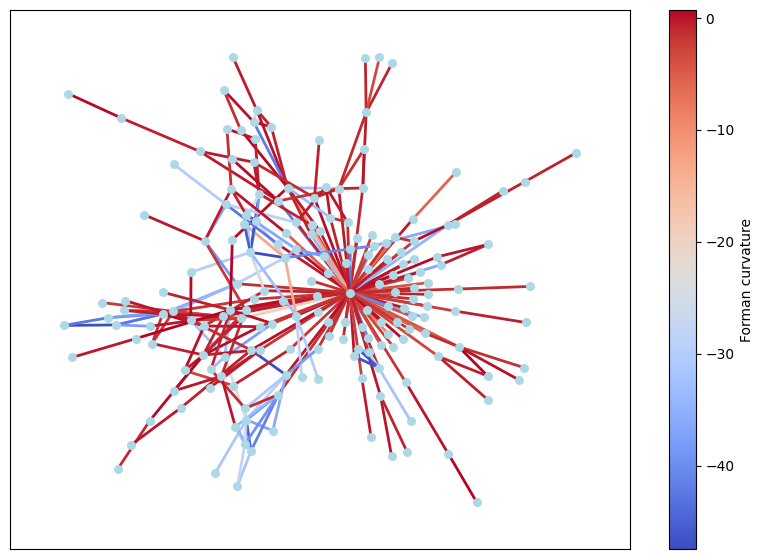

In [ ]:
pos = nx.spring_layout(G)
f,ax = plt.subplots(1,1,figsize=(10,7))
nx.draw_networkx_nodes(G, ax=ax, node_color='lightblue', pos = pos, node_size=30)
#nx.draw_networkx_labels(G, ax=ax, pos= pos,font_size=8)
cmap = plt.cm.coolwarm
norm1 = plt.Normalize(vmin=f1.min(), vmax=f1.max())
nx.draw_networkx_edges(G,ax =ax, edge_color = cmap(norm1(f1)),pos = pos, width=2)
sm1 = plt.cm.ScalarMappable(cmap=cmap, norm=norm1)
plt.colorbar(sm1, ax=ax, label='Forman curvature')
f.show()

In [265]:
B0, F0 = fbc(L0)

In [268]:
display(L0)

array([[0.5610912 , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.404514  , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.37481638, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 1.2432782 , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.04270355,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.18595297]])